# Baseline Catboost Model

In [1]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [9]:
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

,player_id,name_x,position_x,team_x,season_x,conference,usage_passing_downs,usage_standard_downs,usage_third_down,usage_second_down,usage_first_down,usage_rush,usage_var_pass,usage_overall,avg_ppa_passing_downs,avg_ppa_standard_downs,avg_ppa_third_down,avg_ppa_second_down,avg_ppa_first_down,avg_ppa_rush,avg_ppa_var_pass,avg_ppa_all,total_ppa_passing_downs,total_ppa_standard_downs,total_ppa_third_down,total_ppa_second_down,total_ppa_first_down,total_ppa_rush,total_ppa_var_pass,total_ppa_all,fumbles_FUM,fumbles_LOST,fumbles_REC,passing_ATT,passing_COMPLETIONS,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC,college_athlete_id,nfl_athlete_id,college_id,college_team,college_conference,nfl_team_id,nfl_team,position_y,name_y,year,round_x,pick_number,overall,height_in,weight_lbs,pre_draft_position_ranking,pre_draft_grade,pfr_player_id,cfb_player_id,season_y,round_y,pick,team_y,pfr_player_name,position,category,college,w_av,car_av,dr_av,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pfr_id,birth_date,height,weight,rookie_season,last_season,birth_year,age
0,100009,Johnny Jackson,WR,Arizona,2015,PAC,0.104000,0.049000,0.094000,0.065000,0.055000,0.000000,0.133000,0.065000,0.953000,0.413000,1.314000,0.839000,0.415000,NaN,0.674,0.6740,28.600000,13.214000,22.345000,16.772000,9.542000,0.000000,41.813000,41.813000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,50.0,5.0,612.0,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102597,Will Rogers,QB,Washington,2024,B1G,0.670000,0.458333,0.652167,0.532667,0.454333,0.060167,0.888000,0.520333,0.443833,0.188333,0.426833,0.438667,0.138167,-0.1675,0.313,0.2910,57.095833,43.996000,36.587833,45.864333,24.582667,-3.056667,104.148667,101.092333,4.5,2.166667,0.5,336.166667,226.333333,6.166667,0.666333,16.833333,2431.5,7.333333,NaN,NaN,NaN,NaN,NaN,34.000000,17.500000,0.333333,-71.333333,-1.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107494,Trey Sanders,RB,TCU,2024,B12,0.043400,0.068400,0.047267,0.071533,0.058267,0.119733,0.008867,0.060600,0.646133,0.010467,0.280800,-0.090933,-0.006867,0.1442,NaN,0.1604,2.071933,2.040267,3.381200,-0.835133,-0.067467,3.438600,0.674133,4.112733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.466667,15.333333,2.066667,128.733333,4.173333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109907,Jon Lee,RB,Air Force,2014,MWC,0.035000,0.025000,0.015000,0.057000,0.015000,0.023000,0.052000,0.028000,0.630000,-0.128000,-0.363000,0.173000,0.222000,0.1790,0.015,0.1240,1.890000,-0.770000,-0.363000,1.040000,0.444000,1.076000,0.044000,1.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,0.0,12.0,6.0,6.000000,32.000000,0.000000,39.000000,6.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,136429,Cedric Patterson III,WR,Rice,2022,CUSA,0.077333,0.033667,0.116667,0.018000,0.045000,0.022667,0.086667,0.050667,0.224000,0.066333,0.166000,NaN,0.191333,0.1360,0.150,0.1760,6.349333,6.364667,3.909000,2.029667,6.775333,0.465333,12.248333,12.714000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,15.333333,0.333333,16.000000,7.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
merged.columns

Index(['player_id', 'name_x', 'position_x', 'team_x', 'season_x', 'conference',
       'usage_passing_downs', 'usage_standard_downs', 'usage_third_down',
       'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass',
       'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs',
       'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down',
       'avg_ppa_rush', 'avg_ppa_var_pass', 'avg_ppa_all',
       'total_ppa_passing_downs', 'total_ppa_standard_downs',
       'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down',
       'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM',
       'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS',
       'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS',
       'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD',
       'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC', 

In [150]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)
merged.dropna(axis = 0, subset = 'overall', inplace=True)
merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']
merged.fillna(value={'INT_pct' : 0}, inplace=True)
X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]
y = merged['w_av'].fillna(value=0)


X

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
13,WR,0.026000,-0.166000,-1.163000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,1.000000,0.000000,-3.000000,-3.000000,2.000000,0.000000,30.000000,15.000000,25.0,72.0,190.0
15,QB,0.475000,0.341000,173.161000,B12,0.000000,0.000000,428.0,270.0,0.631,0.016355,29.0,3855.0,9.00,0.000000,0.000000,0.000000,0.000000,84.000000,6.000000,101.000000,1.200000,24.0,75.0,226.0
37,TE,0.036000,0.481000,12.016000,PAC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,21.000000,2.000000,197.000000,9.400000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,250.0
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.000000,392.0,228.0,0.582,0.028061,7.0,2214.0,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,RB,0.266167,0.161167,33.282500,ACC,1.666667,0.833333,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,47.500000,2.500000,354.000000,7.133333,202.166667,11.166667,910.500000,4.833333,21.0,72.0,201.0
10554,RB,0.214000,0.273500,50.862000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,16.166667,0.333333,133.833333,8.366667,174.000000,14.333333,1012.666667,5.933333,21.0,68.0,201.0
10645,WR,0.100667,1.259333,68.872667,MWC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,60.333333,9.000000,916.000000,15.200000,0.000000,0.000000,0.000000,0.000000,22.0,72.0,195.0
10661,TE,0.127500,0.784167,77.936500,MAC,0.000000,0.000000,1.5,0.5,0.250,0.000000,0.0,4.5,2.25,76.333333,7.166667,1019.000000,13.250000,10.833333,1.166667,55.000000,5.450000,21.0,76.0,241.0


In [151]:
X.isna().sum()

,0
position_x,0
usage_overall,0
avg_ppa_all,0
total_ppa_all,0
conference,0
fumbles_FUM,0
fumbles_LOST,0
passing_ATT,0
passing_COMPLETIONS,0
passing_PCT,0


In [152]:
na_idx = X[X.isna().any(axis=1)].index
print(na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

Index([114, 229, 4314, 7510], dtype='int64')


In [153]:
y_nona

,w_av
10,9.0
13,0.0
15,4.0
37,0.0
45,16.0
...,...
10096,1.0
10554,3.0
10645,0.0
10661,5.0


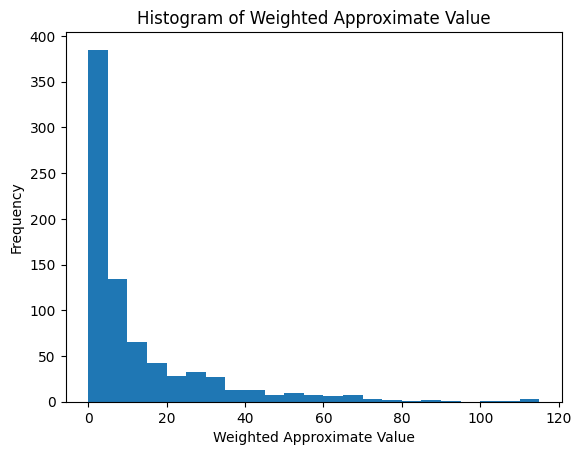

In [154]:
bin_width = 5

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

plt.hist(y_nona, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Weighted Approximate Value')
plt.title('Histogram of Weighted Approximate Value')
plt.show()

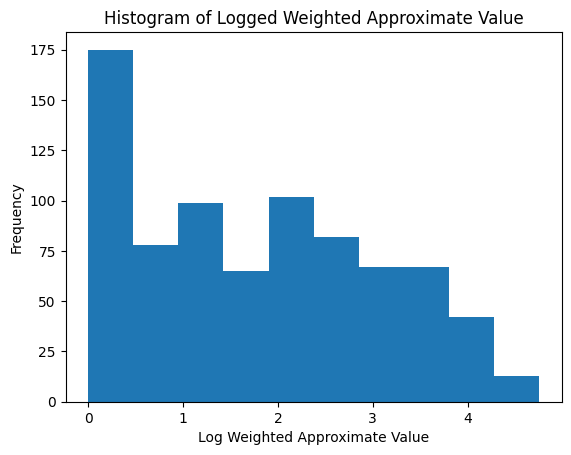

In [155]:
y_log = y_nona.copy()
y_log = np.log(y_log + 1)

plt.hist(y_log)
plt.ylabel('Frequency')
plt.xlabel('Log Weighted Approximate Value')
plt.title('Histogram of Logged Weighted Approximate Value')
plt.show()

In [139]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_log, test_size = 0.3)

num_cols = train_x.select_dtypes(include=np.number).columns
cat_cols = train_x.select_dtypes(include='object').columns


# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

# Fit on training data, transform both
train_x = preprocessor.fit_transform(train_x)
test_x = preprocessor.transform(test_x)

In [140]:
train_x

,usage_overall,avg_ppa_all,total_ppa_all,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight,position_x,conference
759,-0.583905,1.245843,0.067718,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,0.523636,1.14294,0.711029,0.774389,-0.659988,-0.514971,-0.537317,2.692135,0.320701,-0.463367,-0.739354,WR,AAC
762,-0.816833,0.764311,-0.440942,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,0.171829,0.25194,0.174061,0.361081,-0.698657,-0.651627,-0.618107,-0.739073,-0.612707,0.944556,1.281163,TE,B12
656,0.699594,-1.313955,-0.399987,1.184548,2.391305,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,-0.373128,-0.91626,-0.699486,-0.420647,2.238876,1.398215,2.020193,0.706534,0.320701,-1.871290,-0.065848,RB,SBC
111,0.430529,-1.106097,-0.184672,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,0.040763,-0.44106,-0.160225,0.122949,1.866368,1.193230,1.545590,0.639035,-0.612707,-1.519309,0.293355,RB,SEC
39,-0.914793,3.707128,0.272107,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,0.082152,2.52894,1.388774,2.865566,-0.698657,-0.651627,-0.618107,-0.739073,0.320701,-0.111386,-0.784254,WR,B1G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,-0.915881,2.102194,-0.211766,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,-0.083404,1.29144,0.243762,0.982412,-0.698657,-0.651627,-0.618107,-0.739073,1.254109,-0.463367,-0.290350,WR,B1G
166,-0.536013,-0.215840,-0.298538,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,1.189311,0.96969,0.753560,0.213275,-0.698657,-0.651627,-0.618107,-0.739073,1.254109,0.592575,0.428056,WR,B12
761,-0.377535,0.556768,0.079451,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,1.848087,1.24194,1.212138,0.087914,-0.612726,-0.555968,-0.532029,0.370913,0.320701,-1.519309,-2.086365,WR,B12
773,-0.667933,0.273210,-0.569409,-0.333149,-0.281193,-0.391039,-0.388332,-0.443973,-0.185803,-0.379583,-0.388918,-0.418791,0.479488,-0.17376,0.196072,0.211633,-0.656121,-0.610630,-0.559057,1.021530,0.320701,-1.871290,-1.906764,WR,B12


In [165]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['object', 'category']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    l2_leaf_reg = 10,
    verbose=100
)

model.fit(
    train_x,
    train_y,
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 1.3266120	total: 15.8ms	remaining: 31.5s
100:	learn: 1.0855081	total: 1.1s	remaining: 20.8s
200:	learn: 0.9640776	total: 2.27s	remaining: 20.3s
300:	learn: 0.8598366	total: 3.56s	remaining: 20.1s
400:	learn: 0.7731453	total: 4.7s	remaining: 18.8s
500:	learn: 0.7028052	total: 5.92s	remaining: 17.7s
600:	learn: 0.6445229	total: 6.88s	remaining: 16s
700:	learn: 0.5956453	total: 7.41s	remaining: 13.7s
800:	learn: 0.5488304	total: 7.86s	remaining: 11.8s
900:	learn: 0.5089583	total: 8.9s	remaining: 10.9s
1000:	learn: 0.4713960	total: 9.96s	remaining: 9.94s
1100:	learn: 0.4400324	total: 10.9s	remaining: 8.86s
1200:	learn: 0.4127747	total: 11.3s	remaining: 7.5s
1300:	learn: 0.3883034	total: 11.7s	remaining: 6.31s
1400:	learn: 0.3670941	total: 12.2s	remaining: 5.2s
1500:	learn: 0.3458816	total: 12.6s	remaining: 4.2s
1600:	learn: 0.3252551	total: 13s	remaining: 3.25s
1700:	learn: 0.3072107	total: 13.5s	remaining: 2.37s
1800:	learn: 0.2911531	total: 13.9s	remaining: 1.54s
1900:	learn: 0

In [166]:
print(f"{"="*10}Raw Predictions{"="*10}\n{preds}")
print(f"{"="*10}Exponentiated Predictions{"="*10}\n{np.exp(preds) - 1}")

==========Raw Predictions==========
[2.92413617 1.54475469 2.1502225  2.53037757 3.07096599 1.32112914
 0.93575679 2.7009986  2.9265009  1.67503543 2.22030425 1.57437396
 1.06370108 2.78948884 0.89474272 1.48062501 3.52997228 2.92229163
 1.2033457  1.62933553 1.85910891 2.55231782 1.43160384 1.90399618
 1.32444478 2.30816743 2.06431274 0.88261207 1.92399267 3.74368739
 1.42026594 2.72214665 1.17257979 2.18282141 2.21066021 1.15563031
 1.76050741 2.4648434  2.73218253 2.90714134 3.39105974 1.62445236
 1.0080784  1.69914964 1.53528229 2.47851542 1.80783736 2.61609247
 2.53525006 1.82334712 1.94003521 1.80237414 2.36630275 2.02505288
 0.58990846 0.91553559 1.74110285 3.46696189 1.8096201  0.20642489
 1.78743406 2.72739356 1.987633   1.50369086 1.57819156 1.88649502
 1.50625491 2.64231776 1.35949735 2.4616014  2.06615323 1.87487755
 1.06583872 1.8716125  1.02015519 0.46859105 0.67984603 1.13213014
 1.72893233 2.07138889 2.57611563 2.33468914 1.27862302 1.30258144
 0.90001288 1.34089758 2.9

In [167]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y_exp, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 14.88


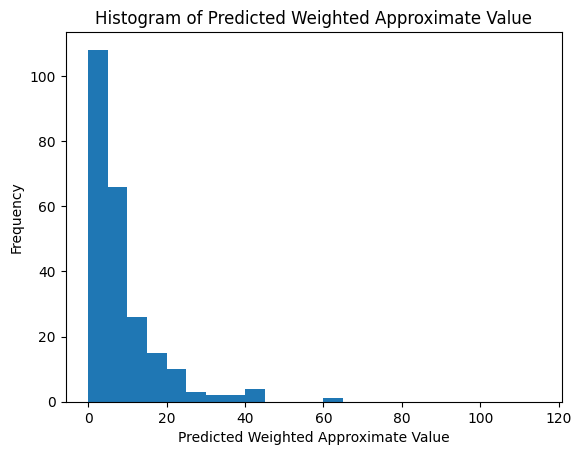

In [168]:
plt.hist(preds_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

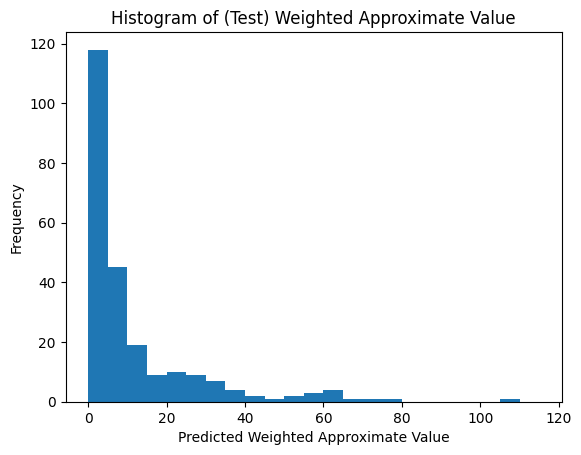

In [169]:
plt.hist(test_y_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [178]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 1.3095195	total: 5.25ms	remaining: 10.5s
1000:	learn: 0.5686840	total: 4.91s	remaining: 4.9s
1999:	learn: 0.3483437	total: 10.6s	remaining: 0us
0:	learn: 1.3140901	total: 14.7ms	remaining: 29.4s
1000:	learn: 0.5485566	total: 5.38s	remaining: 5.37s
1999:	learn: 0.3341321	total: 10.1s	remaining: 0us
0:	learn: 1.3118209	total: 5.66ms	remaining: 11.3s
1000:	learn: 0.5291132	total: 6.18s	remaining: 6.17s
1999:	learn: 0.2976971	total: 10.8s	remaining: 0us
0:	learn: 1.3185498	total: 6.04ms	remaining: 12.1s
1000:	learn: 0.5299435	total: 6.37s	remaining: 6.35s
1999:	learn: 0.3130691	total: 11.1s	remaining: 0us
0:	learn: 1.3219865	total: 5.05ms	remaining: 10.1s
1000:	learn: 0.5601119	total: 5.6s	remaining: 5.58s
1999:	learn: 0.3401839	total: 11s	remaining: 0us
0:	learn: 1.3186474	total: 5.86ms	remaining: 11.7s
1000:	learn: 0.5708905	total: 4.79s	remaining: 4.78s
1999:	learn: 0.3395417	total: 11.1s	remaining: 0us
0:	learn: 1.3004006	total: 5.24ms	remaining: 10.5s
1000:	learn: 0.5372837	

In [176]:
y_log.describe()

,w_av
count,790.000000
mean,1.750254
std,1.323996
min,0.000000
25%,0.693147
50%,1.791759
75%,2.833213
max,4.753590


# RandomForest

In [189]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 17.56


# **XGBoost**

In [190]:
! pip install xgboost

In [198]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[0]	validation_0-rmse:1.36877
[999]	validation_0-rmse:1.37385
[0]	validation_0-rmse:1.32172
[999]	validation_0-rmse:1.26392
[0]	validation_0-rmse:1.34365
[999]	validation_0-rmse:1.40261
[0]	validation_0-rmse:1.28757
[999]	validation_0-rmse:1.28755
[0]	validation_0-rmse:1.25051
[999]	validation_0-rmse:1.22918
[0]	validation_0-rmse:1.28444
[999]	validation_0-rmse:1.12507
[0]	validation_0-rmse:1.44503
[999]	validation_0-rmse:1.34648
[0]	validation_0-rmse:1.24583
[999]	validation_0-rmse:1.33258
[0]	validation_0-rmse:1.38605
[999]	validation_0-rmse:1.27482
[0]	validation_0-rmse:1.18690
[999]	validation_0-rmse:1.27597
CV RMSE: 17.3
